In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# predicting freight cost. 
## the objective is to predict freight cose using quantity and sales dollars , which can improve cost forecasting , budgetting and help in vendor negotiations

In [2]:
#establishing connection
conn=sqlite3.connect("/Users/Kabir/Desktop/my SALES ANALYSIS/inventory.db")
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)

In [3]:
for table in tables['name']:
    if table!="sales":
        print(table)
        df=pd.read_sql_query(f"select * from {table} limit 5",conn)
        display(df)
    

begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


purchases


...

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


vendor_sales_summary


,VendorNumber,VendorName,Brand,Description,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [4]:
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)

In [24]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [26]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


<Axes: >

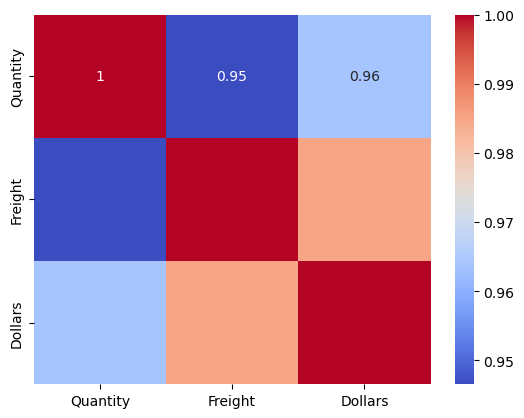

In [28]:
# we see relation between quatity and dollars 
# it is a natural fact that they are highly related to freight cost
#lets check how are they related using scatter plot and heatmap
sns.heatmap(vendor_df[['Quantity','Freight','Dollars']].corr(), annot=True, cmap='coolwarm')

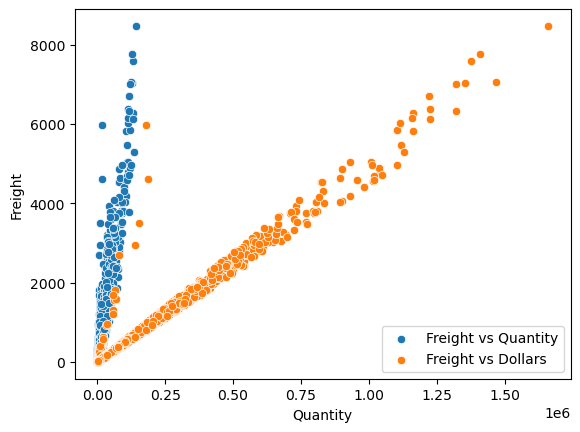

In [31]:
#now that they are related lets create a scatter plot to check it visibly
sns.scatterplot(data=vendor_df, x='Quantity', y='Freight', label='Freight vs Quantity'); sns.scatterplot(data=vendor_df, x='Dollars', y='Freight', label='Freight vs Dollars'); plt.legend(); plt.show()

<Axes: xlabel='Quantity', ylabel='Freight_per_Unit'>

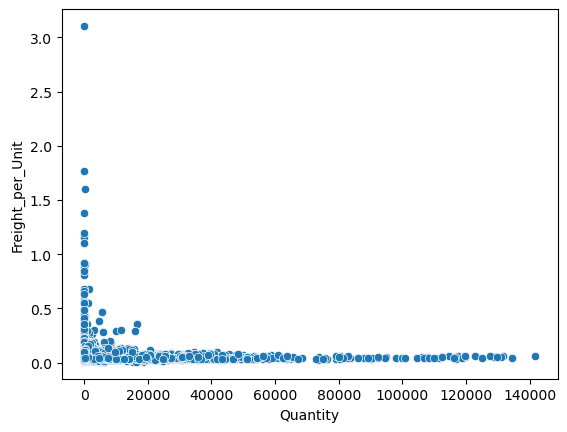

In [19]:

# this is efficiency check , it shows how each vendor pays the freigh cost compared to the quatityb
vendor_df['Freight_per_Unit'] = vendor_df['Freight'] / vendor_df['Quantity']
sns.scatterplot(data=vendor_df, x='Quantity', y='Freight_per_Unit')


In [20]:
#we try to find  threshold values for quantity and check the respective groups relation with freight
high_quantity=vendor_df['Quantity'].quantile(0.75)
low_quantity=vendor_df['Quantity'].quantile(0.25)


In [21]:
high_quantity


5100.5

In [22]:
low_quantity


83.0

In [23]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'Freight_per_Unit'].mean()

0.09489854253138316

In [24]:
vendor_df.loc[vendor_df['Quantity']>high_quantity,'Freight_per_Unit'].mean()

0.049077654690759046

In [25]:
# we find that vendors who order in bulk have lesser freight cost which saves approximately
# Define bulk threshold (median quantity)
bulk_threshold = vendor_df['Quantity'].median()

# Create Freight per Unit column
vendor_df['Freight_per_Unit'] = vendor_df['Freight'] / vendor_df['Quantity']

# Separate bulk vs non-bulk
bulk_df = vendor_df[vendor_df['Quantity'] > bulk_threshold]
non_bulk_df = vendor_df[vendor_df['Quantity'] <= bulk_threshold]

# Baseline freight per unit (non-bulk average)
baseline_fpu = non_bulk_df['Freight_per_Unit'].mean()

# Bulk freight per unit
bulk_fpu = bulk_df['Freight_per_Unit'].mean()

# Approx total dollars saved
total_savings = (baseline_fpu - bulk_fpu) * bulk_df['Quantity'].sum()

print(f"Approximate Dollars Saved by Bulk Vendors: {total_savings:,.2f}")


Approximate Dollars Saved by Bulk Vendors: 889,114.00


1825961.7720261207

In [57]:
x=vendor_df[['Dollars']]
y=vendor_df['Freight']


In [48]:
from sklearn.model_selection import train_test_split


In [58]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)


In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [60]:
model1=LinearRegression()
model1.fit(xtrain,ytrain)

model2=DecisionTreeRegressor(max_depth=4)
model2.fit(xtrain,ytrain)

model3=RandomForestRegressor(max_depth=4)
model3.fit(xtrain,ytrain)


RandomForestRegressor(max_depth=4)

In [61]:
def evaluate_model(model,xtest,ytest,model_name):
    pred=model.predict(xtest)
    mae=mean_absolute_error(ytest,pred)
    mse=mean_squared_error(ytest,pred)
    r2=r2_score(ytest,pred)*100

    print(f"\n{model_name}:Performance")
    print(f"MAE: {mae}")
    print(f"MSE:{mse}")
    print(f"R2:{r2:.2f}")

In [62]:
evaluate_model(model1,xtest,ytest,'LinearRegression')
evaluate_model(model2,xtest,ytest,'DecisionTreeRegressor')
evaluate_model(model3,xtest,ytest,'RandomForestRegressor')


LinearRegression:Performance
MAE: 24.1059770728758
MSE:15555.318371054229
R2:96.99

DecisionTreeRegressor:Performance
MAE: 38.116549884696504
MSE:19112.513744786862
R2:96.30

RandomForestRegressor:Performance
MAE: 30.506493910883005
MSE:17217.59641196741
R2:96.67


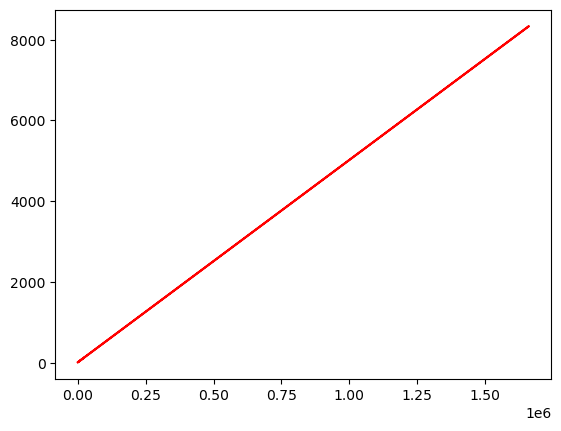

In [63]:

plt.plot(xtest,model1.predict(xtest),color='red')

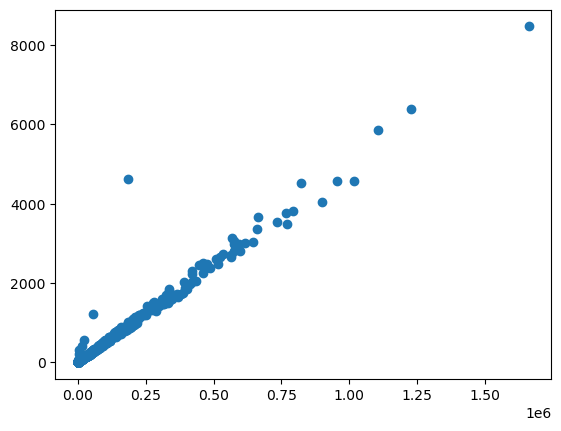

In [64]:
plt.scatter(xtest,ytest)

In [65]:
input_data={
    "Dollars":[18500,9000],}
df=pd.DataFrame(input_data)


In [66]:
model1.predict(df)


array([97.78868161, 50.14455838])